# LAB 02 – House Prices: Advanced Regression Techniques

**Mục tiêu:** xây dựng mô hình hồi quy dự đoán `SalePrice` theo quy trình CRISP-DM, từ hiểu bài toán → hiểu/khám phá dữ liệu → tiền xử lý & feature engineering → modeling/tuning → đánh giá → tạo file submission Kaggle.

# So lets begin with complete EDA...

In [67]:
import pandas as pd 
import numpy as np
import matplotlib. pyplot as plt
import seaborn as sns
import pickle

In [68]:
import os

print("Current directory:", os.getcwd())
print(os.listdir())

Current directory: d:\sgu-MAYHOC\lab02\data
['.keep', 'data_description.txt', 'lab02_house_price_CRISP.ipynb', 'sample_submission.csv', 'sample_sub_dt. csv', 'sample_sub_dt.csv', 'sample_sub_xgb. csv', 'sample_sub_xgb.csv', 'test.csv', 'train.csv', 'xgb_model. pkl']


# Load Data

In [69]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)


Train Shape: (1460, 81)
Test Shape: (1459, 80)


In [70]:
print(train. info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [71]:
print(test. info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

# Train Data

In [72]:
print(train.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


# Test Data

In [73]:
print(test.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


<Axes: >

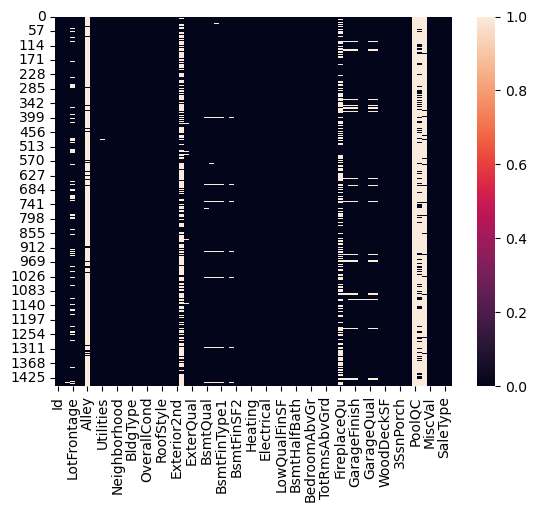

In [74]:
sns.heatmap(test.isnull())

# For Train Data

In [75]:
cat_col_train= ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageQual', 'GarageCond']
ncat_col_train= ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for i in cat_col_train:
    train[i]=train[i].fillna(train[i].mode()[0])

for j in ncat_col_train:
    train[j]=train[j].fillna(train[j].mean())

# For Test Data

In [76]:
cat_col_train= ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageQual', 'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']
ncat_col_train= ['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']

for i in cat_col_train:
    test[i]=train[i].fillna(test[i].mode()[0])

for j in ncat_col_train:
    test[j]=test[j].fillna(test[j].mean())

In [77]:
print(train.columns)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

# Drop Columns

<Axes: >

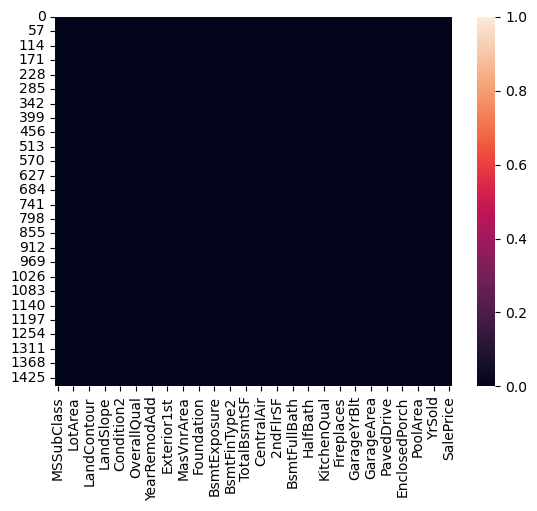

In [78]:


to_drop = ['Id' , 'Alley' , 'PoolQC' , 'Fence' , 'MiscFeature' ]

for k in to_drop:
    train. drop([ k], axis = 1, inplace = True) 
    test. drop([ k], axis = 1, inplace = True)

sns. heatmap(train. isnull())

<Axes: >

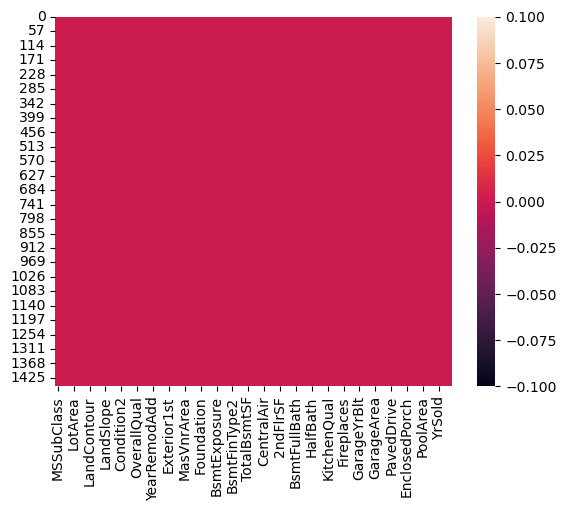

In [79]:
sns. heatmap(test. isnull())

In [80]:
print("Train Shape: ", train.shape)
print("Test Shape: ", test.shape)

Train Shape:  (1460, 76)
Test Shape:  (1459, 75)


It is observed that for some columns in train date few categories are not present but available in test data.So, we will concat test data to train data, then perform one hot encoding on all categorical columns

In [81]:
final_df = pd.concat([train, test], axis=0)
final_df .shape

(2919, 76)

In [82]:
all_cat_col = [ 'MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond','PavedDrive','SaleType','SaleCondition']

def cat_onehot_encoding(multicol):
  df_final = final_df
  i = 0
  for fields in multicol:
      print(fields)

      df1 = pd.get_dummies(final_df[fields], drop_first=True)

      final_df.drop([fields], axis=1, inplace=True)

      if i == 0:
         df_final = df1.copy()
      else:
         df_final = pd.concat([df_final, df1], axis=1)

      i = i + 1

  df_final = pd.concat([final_df, df_final], axis=1)

  return df_final
final_df = cat_onehot_encoding(all_cat_col)

MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition


In [83]:
final_df .shape

(2919, 236)

In [84]:
final_df = final_df.loc[:, ~final_df.columns.duplicated()]
final_df.shape

(2919, 176)

Let's now divide our data to train and test data

In [85]:
df_train = final_df.iloc[:1460,:]
df_test = final_df.iloc[1460:,:]

df_test.drop(['SalePrice'], axis=1, inplace=True)
print("Train Shape: ", df_train.shape)
print("Test Shape: ", df_test.shape)

Train Shape:  (1460, 176)
Test Shape:  (1459, 175)


C:\Users\huong\AppData\Local\Temp\ipykernel_22800\1419522131.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.drop(['SalePrice'], axis=1, inplace=True)


# Training Data

In [86]:
x_train = df_train.drop(['SalePrice'], axis=1)
y_train = df_train['SalePrice']

In [87]:
import xgboost
print(xgboost.__version__)

3.4.1


# XGBoost

In [88]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [89]:
import xgboost


xgb_model = xgboost. XGBRegressor() 
xgb_model. fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

param = {
'n_estimators' : [ 100, 500, 900, 1100, 1500],
'max_depth' :  [ 2, 3, 5, 10, 15],
'learning_rate' : [ 0.05, 0.1, 0.15, 0.2],
'min_child_weight' :  [ 1, 2, 3, 4],
'booster' :  ['gbtree' ,'gblinear' ],
'base_score' : [ 0.25,0.5,0.75, 1]}



from sklearn. model_selection import RandomizedSearchCV
random_cv = RandomizedSearchCV(estimator=xgb_model,
param_distributions = param,cv=5,n_iter=50,
scoring = 'neg_mean_absolute_error',n_jobs =4,
verbose = 5, return_train_score = True, random_state =42)
random_cv.fit(x_train,y_train)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    booster='gbtree',
    learning_rate=0.1,
    max_depth=2,
    min_child_weight=1,
    n_estimators=900,
    objective='reg:squarederror',
    random_state=0,
    n_jobs=-1,
    tree_method='hist'
)

xgb_model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


# Save model

In [ ]:
f = "xgb_model. pkl"
pickle.dump(xgb_model, open(f, 'wb' ))

# Predictions

In [ ]:
pred_xgb = xgb_model. predict(df_test)
print(pred_xgb. shape)

(1459,)


# Submission

In [ ]:
sub_df =pd.read_csv('sample_submission.csv' ) 
sub_df['SalePrice' ] = pred_xgb
sub_df.to_csv('sample_sub_xgb. csv' , index = False)

# Decision Tree

In [ ]:
from sklearn. tree import DecisionTreeClassifier


dt_model =DecisionTreeClassifier() 
dt_model.fit(x_train, y_train)




,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Predictions

In [ ]:
pred_dt = dt_model.predict(df_test) 
print(pred_dt.shape)

(1459,)


# Submissions

In [ ]:
sub_df=pd.read_csv('sample_submission.csv' ) 
sub_df['SalePrice' ] = pred_dt
sub_df.to_csv('sample_sub_dt. csv', index = False)

# Artificial Neural Network

In [ ]:
%pip install keras tensorflow

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.4 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.4 MB 1.2 MB/s eta 0:00:02
   ------------- -------------------------- 0.8/2.4 MB 1.2 MB/s eta 0:00:02
   ------------- -------------------------- 0.8/2.4 MB 1.2 MB/s eta 0:00:02
   ----------------- ---------------------- 1.0/2.4 MB 986.5 kB/s eta 0:00:02
   --------------------- ------------------ 1.3/2.4 MB 955.2 kB/s eta 0:00:02
   --------------------- ------------------ 1.3/2.4 MB 955.2 kB/s eta 0:00:02
   -------------------------- ------------- 1.6/2.4 MB 874.1 kB/s eta 0:00:01
   ------------------------------ --------- 1.8/2.4 MB 926.7 kB/s eta 0:00:01
   -------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.36.2 which is incompatible.


In [ ]:
import keras

from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout



def root_mean_squared_error(y_true, y_pred):
    return keras.ops.sqrt(
        keras.ops.mean(keras.ops.square(y_pred - y_true))
    )

# Model

In [ ]:
nn_model = Sequential()

nn_model.add(Dense(
    50,
    kernel_initializer='he_uniform',
    activation='relu',
    input_dim=x_train.shape[1]
))
nn_model.add(Dense(25, kernel_initializer='he_uniform', activation='relu'))
nn_model.add(Dense(50, kernel_initializer='he_uniform', activation='relu'))
nn_model.add(Dense(1, kernel_initializer='he_uniform'))

nn_model.compile(
    loss=root_mean_squared_error,
    optimizer='Adamax'
)

nn_model.fit(
    x_train.values,
    y_train.values,
    validation_split=0.25,
    batch_size=10,
    epochs=1000
)

Epoch 1/1000


C:\Users\huong\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 180165.7812 - val_loss: 148954.0781
Epoch 2/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 99491.2891 - val_loss: 62580.7344
Epoch 3/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 68533.6953 - val_loss: 61115.8516
Epoch 4/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 66585.4531 - val_loss: 60283.6641
Epoch 5/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 64569.0664 - val_loss: 58782.0312
Epoch 6/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 62918.5742 - val_loss: 57736.6484
Epoch 7/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 60694.3164 - val_loss: 56705.8906
Epoch 8/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 58852.3008 - val_loss: 55827.4922
Epoch 9/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 58162.3164 - val_loss: 54865.7812
Epoch 10/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56294.0391 - val_loss: 53790.1055
Epoch 11/1000
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

In [92]:
nn_model.save('nn_model.h5' )

# Predictions

In [ ]:
pred_nn =nn_model. predict(df_test) 
print(pred_nn.shape)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
(1459, 1)


# Submission

In [100]:
sub_df= pd.read_csv('sample_submission.csv' )
sub_df['SalePrice' ]  =  pred_nn
sub_df.to_csv(' sample_sub_nn.csv' , index = False)